# [Контест](https://www.kaggle.com/competitions/games-rating/data) на Kaggle

Датасет хранит данные о настольных играх с веб-сайта BoardGameGeek (BGG) в феврале 2021 года. BGG — это крупнейшая онлайн-коллекция данных о настольных играх, которая состоит из данных о более чем 100 000 игр (с рейтингом и без рейтинга).

В данном соревновании необходимо реализовать линейную регрессию, которая сможет предсказывать средний рейтинг игры (`Rating Average`).

In [ ]:
%pip install opendatasets
import opendatasets as od

In [ ]:
od.download_kaggle_dataset("https://www.kaggle.com/competitions/games-rating/data", "")

Skipping, found downloaded files in "games-rating" (use force=True to force download)


## Данные: анализ и обработка

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("games-rating/train_data.csv")

In [ ]:
print(len(df))
df

15257


,ID,Name,Year Published,Min Players,Max Players,Play Time,Min Age,Users Rated,Rating Average,BGG Rank,Complexity Average,Owned Users,Mechanics,Domains
0,174430.0,Gloomhaven,2017.0,1,4,120,14,42055,"8,79",1,"3,86",68323.0,"Action Queue, Action Retrieval, Campaign / Bat...","Strategy Games, Thematic Games"
1,224517.0,Brass: Birmingham,2018.0,2,4,120,14,19217,"8,66",3,"3,91",28785.0,"Hand Management, Income, Loans, Market, Networ...",Strategy Games
2,167791.0,Terraforming Mars,2016.0,1,5,120,12,64864,"8,43",4,"3,24",87099.0,"Card Drafting, Drafting, End Game Bonuses, Han...",Strategy Games
3,233078.0,Twilight Imperium: Fourth Edition,2017.0,3,6,480,14,13468,"8,70",5,"4,22",16831.0,"Action Drafting, Area Majority / Influence, Ar...","Strategy Games, Thematic Games"
4,291457.0,Gloomhaven: Jaws of the Lion,2020.0,1,4,120,14,8392,"8,87",6,"3,55",21609.0,"Action Queue, Campaign / Battle Card Driven, C...","Strategy Games, Thematic Games"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15252,1410.0,Trouble,1965.0,2,4,45,4,3255,"3,79",20339,"1,05",4962.0,Roll / Spin and Move,Children's Games
15253,16398.0,War,0.0,2,2,30,4,1340,"2,28",20340,1,427.0,NaN,Children's Games
15254,5048.0,Candy Land,1949.0,2,4,30,3,4006,"3,18",20342,"1,08",5788.0,Roll / Spin and Move,Children's Games
15255,5432.0,Chutes and Ladders,-200.0,2,6,30,3,3783,"2,86",20343,"1,02",4400.0,"Dice Rolling, Grid Movement, Race, Roll / Spin...",Children's Games


In [ ]:
df.dtypes

,0
ID,float64
Name,object
Year Published,float64
Min Players,int64
Max Players,int64
Play Time,int64
Min Age,int64
Users Rated,int64
Rating Average,object
BGG Rank,int64


По какой-то причине, значения `Rating Average` и `Complexity Average` представлены в виде чисел с плавающей точкой, однако разделитель в них - запятая (из-за чего `pandas` не воспринимает их как `float64`).

Поправим это:

In [ ]:
df["Rating Average"] = df["Rating Average"].astype(str).str.replace(",", ".").astype("float64")
df["Complexity Average"] = df["Complexity Average"].astype(str).str.replace(",", ".").astype("float64")

df.dtypes


,0
ID,float64
Name,object
Year Published,float64
Min Players,int64
Max Players,int64
Play Time,int64
Min Age,int64
Users Rated,int64
Rating Average,float64
BGG Rank,int64


Характеристики игры:
* `ID` - Идентификатор настольной игры
* `Name` - Имя
* `Year Published` - Год публикации
* `Min Players` - Рекомендуемое минимальное количество игроков
* `Max Players` - Рекомендуемое максимальное количество игроков
* `Play Time` - Время игры
* `Min Age` - Рекомендуемый минимальный возраст игроков
* `Users Rated` - Количество пользователей, оценивших игру
* `Rating Average` - Средний рейтинг, полученный игрой (целевая переменная)
* `BGG Rank` - Рейтинг от BGG
* `Complexity Average` - Среднее значение сложности игры
* `Owned Users` - Количество зарегистрированных BGG владельцев игры
* `Mechanics` - Механика, используемая в игре
* `Domains` - Домены настольных игр, которым принадлежит игра

In [ ]:
df.isna().sum()

,0
ID,10
Name,0
Year Published,1
Min Players,0
Max Players,0
Play Time,0
Min Age,0
Users Rated,0
Rating Average,0
BGG Rank,0


In [ ]:
#df = df.dropna()  # Привет из будущего: после удаления пропусков, удается пробить барьер в 0.36 MSE (хотя мне удавалось дойти до 0.3 и так)
                  # На самом деле в этом есть логика - игры, мало кому интересные, скорее всего почти не будут оценены

Пустых данных в основных численных колонках почти нет, поэтому очистка датасета не требуется. Что делать с `Mechanics` и `Domains` будет указано потом.

Очевидно, что идентификатор игры в базе данных и её название никак не влияют на целевую переменную - **удалим `ID` и `Name`** из датасета

In [ ]:
#df = df.drop(["ID", "Name"], axis=1)
df = df.drop(["Name"], axis=1)

`Mechanics` и `Domains` - важные характеристики, однако они не являются числовыми.

Проанализируем их:

In [ ]:
CATEGORIAL_FEATURES = ["Mechanics", "Domains"]
NON_CATEGORIAL_FEATURES = list(df.drop(CATEGORIAL_FEATURES + ["Rating Average"], axis=1).columns)

In [ ]:
medians = {}
for col in NON_CATEGORIAL_FEATURES:
    non_zero_values = df[df[col] != 0][col]
    if len(non_zero_values) > 0:
        medians[col] = non_zero_values.median()
    else:
        medians[col] = df[col].median()

for col in NON_CATEGORIAL_FEATURES:
    zero_mask = df[col] == 0
    df.loc[zero_mask, col] = medians[col]
    df[col] = df[col].fillna(medians[col])

In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer

In [ ]:
df['Mechanics_list'] = df['Mechanics'].fillna('').apply(
    lambda x: [item.strip() for item in x.split(', ')] if x else []
)

mlb_mechanics = MultiLabelBinarizer()
mechanics_encoded = mlb_mechanics.fit_transform(df['Mechanics_list'])
mechanics_df = pd.DataFrame(
    mechanics_encoded,
    columns=[f"Mechanics_{c}" for c in mlb_mechanics.classes_],
    index=df.index
)

In [ ]:
df['Domains_list'] = df['Domains'].fillna('').apply(
    lambda x: [item.strip() for item in x.split(', ')] if x else []
)

mlb_domains = MultiLabelBinarizer()
domains_encoded = mlb_domains.fit_transform(df['Domains_list'])
domains_df = pd.DataFrame(
    domains_encoded,
    columns=[f"Domains_{c}" for c in mlb_domains.classes_],
    index=df.index
)

In [ ]:
df = df.drop(['Mechanics', 'Domains', 'Mechanics_list', 'Domains_list'], axis=1)

train_df = pd.concat([df, mechanics_df, domains_df], axis=1)
train_df

,ID,Year Published,Min Players,Max Players,Play Time,Min Age,Users Rated,Rating Average,BGG Rank,Complexity Average,...,Mechanics_Worker Placement with Dice Workers,Mechanics_Zone of Control,Domains_Abstract Games,Domains_Children's Games,Domains_Customizable Games,Domains_Family Games,Domains_Party Games,Domains_Strategy Games,Domains_Thematic Games,Domains_Wargames
0,174430.0,2017.0,1,4,120,14,42055,8.79,1,3.86,...,0,0,0,0,0,0,0,1,1,0
1,224517.0,2018.0,2,4,120,14,19217,8.66,3,3.91,...,0,0,0,0,0,0,0,1,0,0
2,167791.0,2016.0,1,5,120,12,64864,8.43,4,3.24,...,0,0,0,0,0,0,0,1,0,0
3,233078.0,2017.0,3,6,480,14,13468,8.70,5,4.22,...,0,0,0,0,0,0,0,1,1,0
4,291457.0,2020.0,1,4,120,14,8392,8.87,6,3.55,...,0,0,0,0,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15252,1410.0,1965.0,2,4,45,4,3255,3.79,20339,1.05,...,0,0,0,1,0,0,0,0,0,0
15253,16398.0,2011.0,2,2,30,4,1340,2.28,20340,1.00,...,0,0,0,1,0,0,0,0,0,0
15254,5048.0,1949.0,2,4,30,3,4006,3.18,20342,1.08,...,0,0,0,1,0,0,0,0,0,0
15255,5432.0,-200.0,2,6,30,3,3783,2.86,20343,1.02,...,0,0,0,1,0,0,0,0,0,0


## Анализ корреляции признаков

Посмотрим на корреляцию признаков (вычислить ее с учетом того, что часть признаков мы закодировали - нельзя, поэтому будем визуализировать без них)

In [ ]:
import numpy as np

In [ ]:
numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()

encoded_cols = [col for col in train_df.columns if col.startswith('Mechanics_') or col.startswith('Domains_')]
corr_cols = [col for col in numeric_cols if col not in encoded_cols and col != 'Rating Average']

correlation_matrix = train_df[corr_cols + ['Rating Average']].corr()
correlation_matrix

,ID,Year Published,Min Players,Max Players,Play Time,Min Age,Users Rated,BGG Rank,Complexity Average,Owned Users,Rating Average
ID,1.000000,0.151556,-0.118227,0.018797,-0.031124,0.092032,-0.013422,-0.236638,-0.037605,0.008763,0.399436
Year Published,0.151556,1.000000,-0.009321,0.007426,-0.002806,0.061928,-0.016104,-0.053053,-0.000642,-0.010753,0.083240
Min Players,-0.118227,-0.009321,1.000000,0.107446,0.028671,0.018422,-0.018374,0.099097,-0.176957,-0.030449,-0.157304
Max Players,0.018797,0.007426,0.107446,1.000000,-0.007467,0.002107,0.001659,0.029521,-0.096384,0.003468,-0.044155
Play Time,-0.031124,-0.002806,0.028671,-0.007467,1.000000,0.076051,-0.004357,-0.040013,0.176875,-0.002600,0.079229
Min Age,0.092032,0.061928,0.018422,0.002107,0.076051,1.000000,0.052762,-0.238475,0.476292,0.063942,0.306922
Users Rated,-0.013422,-0.016104,-0.018374,0.001659,-0.004357,0.052762,1.000000,-0.321523,0.087781,0.984080,0.175867
BGG Rank,-0.236638,-0.053053,0.099097,0.029521,-0.040013,-0.238475,-0.321523,1.000000,-0.368126,-0.342339,-0.737897
Complexity Average,-0.037605,-0.000642,-0.176957,-0.096384,0.176875,0.476292,0.087781,-0.368126,1.000000,0.088781,0.495965
Owned Users,0.008763,-0.010753,-0.030449,0.003468,-0.002600,0.063942,0.984080,-0.342339,0.088781,1.000000,0.184801


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

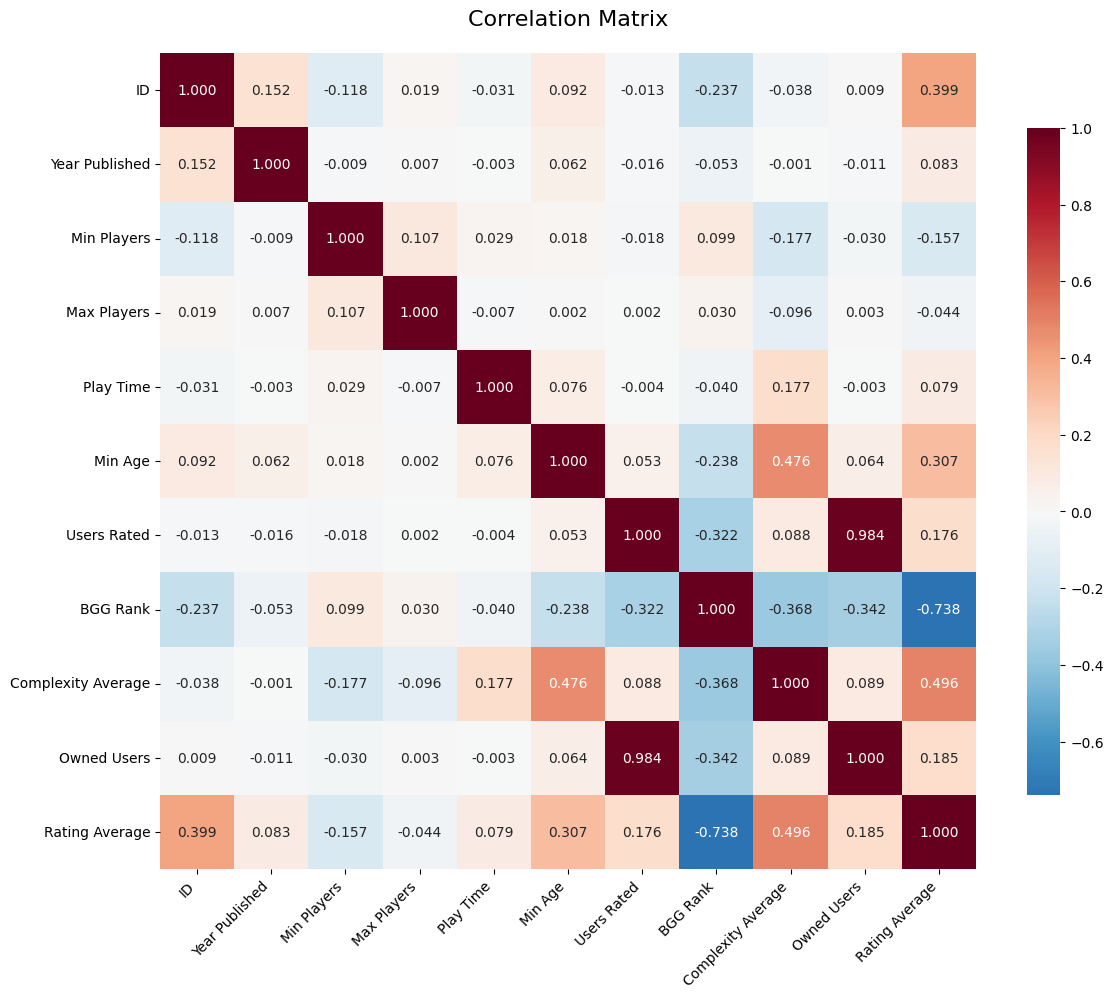

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix,
            annot=True,
            cmap="RdBu_r",
            center=0,
            fmt=".3f",
            square=True,
            cbar_kws={"shrink": 0.8},
            annot_kws={"size": 10})

plt.title("Correlation Matrix", fontsize=16, pad=20)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
train_df.isna().sum()

,0
ID,0
Year Published,0
Min Players,0
Max Players,0
Play Time,0
...,...
Domains_Family Games,0
Domains_Party Games,0
Domains_Strategy Games,0
Domains_Thematic Games,0


Остался один объект с неразмеченным `Year Published`.

Заменим ему год на моду всей колонки:

In [ ]:
train_df["ID"] = train_df["ID"].fillna(train_df["ID"].mode()[0])
train_df["Year Published"] = train_df["Year Published"].fillna(train_df["Year Published"].median())

### Feature Engineering

Добавим новые признаки для улучшения качества модели

In [ ]:
train_df["player_range"] = train_df["Max Players"] - train_df["Min Players"]
train_df["player_flexibility"] = train_df["player_range"] / (train_df["Min Players"] + 0.0001)
train_df["supports_solo"] = (train_df["Min Players"] == 1).astype(int)
train_df["supports_large_groups"] = (train_df["Max Players"] >= 6).astype(int)

train_df["adult_game"] = (train_df["Min Age"] >= 16).astype(int)
train_df["family_game"] = (train_df["Min Age"] <= 12).astype(int)
train_df["complexity_per_hour"] = train_df["Complexity Average"] / ((train_df["Play Time"] + 0.0001) / 60)

train_df["complexity_squared"] = train_df["Complexity Average"] ** (1/2)
#train_df["play_time_log"] = np.log1p(train_df["Play Time"])

train_df["is_modern"] = (train_df["Year Published"] > 2010).astype(int)

train_df["popularity_density"] = train_df["Users Rated"] / (2024 - train_df["Year Published"] + 1)

### Тестовые данные

## Подготовка данных для PyTorch

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tqdm import tqdm

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
class BoardGameDataset(Dataset):
    def __init__(self, X, y=None):
        self.X = torch.FloatTensor(X.values if hasattr(X, 'values') else X)
        self.y = torch.FloatTensor(y.values if hasattr(y, 'values') else y).reshape(-1, 1) if y is not None else None

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        if self.y is not None:
            return self.X[idx], self.y[idx]
        return self.X[idx]

In [ ]:
X = train_df.drop("Rating Average", axis=1)
y = train_df["Rating Average"]

encoded_cols = [col for col in X.columns if col.startswith('Mechanics_') or col.startswith('Domains_')]
numerical_cols = [col for col in X.columns if col not in encoded_cols]

In [ ]:
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[numerical_cols] = scaler.fit_transform(X[numerical_cols])

X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.1, random_state=42)

In [ ]:
train_dataset = BoardGameDataset(X_train, y_train)
val_dataset = BoardGameDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

## Определение нейронной сети для регрессии

In [ ]:
class RatingPredictor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)


model = RatingPredictor(input_dim=X.shape[1]).to(device)

In [ ]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

In [ ]:
epochs = 50
best_val_loss = float('inf')

train_losses = []
val_losses = []

for epoch in range(1, epochs + 1):
    model.train()
    train_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    avg_val_loss = 0
    if epoch % 10 == 0:
        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

    scheduler.step(avg_val_loss)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | LR: {optimizer.param_groups[0]['lr']:.6f}")

Epoch  10 | Train Loss: 0.1386 | Val Loss: 0.2137 | LR: 0.001000
Epoch  20 | Train Loss: 0.0952 | Val Loss: 0.1571 | LR: 0.000500
Epoch  30 | Train Loss: 0.0736 | Val Loss: 0.1541 | LR: 0.000250
Epoch  40 | Train Loss: 0.0610 | Val Loss: 0.1518 | LR: 0.000125
Epoch  50 | Train Loss: 0.0536 | Val Loss: 0.1541 | LR: 0.000063


In [ ]:
X_combined = pd.concat([X_train, X_val])
y_combined = pd.concat([y_train, y_val])

print(f"Combined dataset size: {len(X_combined)}")

combined_dataset = BoardGameDataset(X_combined, y_combined)
combined_loader = DataLoader(combined_dataset, batch_size=64, shuffle=True)

final_epochs = 10
for epoch in range(1, final_epochs + 1):
    model.train()
    train_loss = 0.0

    for batch_X, batch_y in combined_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(combined_loader)

    if epoch % 5 == 0:
        print(f"Final training epoch {epoch:2d} | Loss: {avg_train_loss:.4f}")

Combined dataset size: 15257
Final training epoch  5 | Loss: 0.0603
Final training epoch 10 | Loss: 0.0582


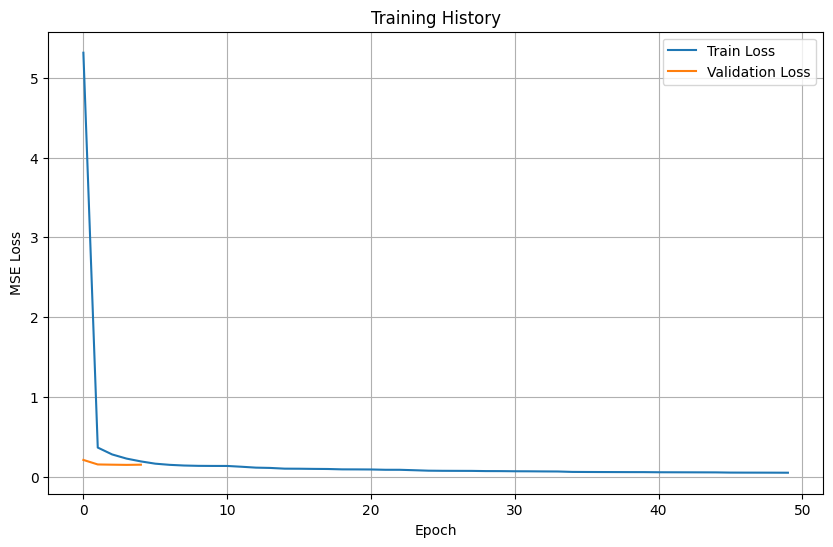

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training History')
plt.legend()
plt.grid(True)
plt.show()

# Запуск на тестовых данных

In [ ]:
test_df = pd.read_csv("games-rating/test_data.csv")

test_df["Complexity Average"] = test_df["Complexity Average"].astype(str).str.replace(",", ".").astype("float64")

test_df = test_df.drop(["Name"], axis=1)
test_df = test_df.drop(["Owned Users"], axis=1)

train_medians = df[NON_CATEGORIAL_FEATURES].median()

for col in NON_CATEGORIAL_FEATURES:
    if col in test_df.columns:
        test_df[col] = test_df[col].fillna(train_medians[col])

test_df['Mechanics_list'] = test_df['Mechanics'].fillna('').apply(
    lambda x: [item.strip() for item in x.split(', ')] if x else []
)
test_mechanics_encoded = mlb_mechanics.transform(test_df['Mechanics_list'])
test_mechanics_df = pd.DataFrame(
    test_mechanics_encoded,
    columns=[f"Mechanics_{c}" for c in mlb_mechanics.classes_],
    index=test_df.index
)

test_df['Domains_list'] = test_df['Domains'].fillna('').apply(
    lambda x: [item.strip() for item in x.split(', ')] if x else []
)
test_domains_encoded = mlb_domains.transform(test_df['Domains_list'])
test_domains_df = pd.DataFrame(
    test_domains_encoded,
    columns=[f"Domains_{c}" for c in mlb_domains.classes_],
    index=test_df.index
)

test_df = test_df.drop(['Mechanics', 'Domains', 'Mechanics_list', 'Domains_list'], axis=1)

test_df = pd.concat([test_df, test_mechanics_df, test_domains_df], axis=1)

test_df["player_range"] = test_df["Max Players"] - test_df["Min Players"]
test_df["player_flexibility"] = test_df["player_range"] / (test_df["Min Players"] + 0.0001)
test_df["supports_solo"] = (test_df["Min Players"] == 1).astype(int)
test_df["supports_large_groups"] = (test_df["Max Players"] >= 6).astype(int)

test_df["adult_game"] = (test_df["Min Age"] >= 16).astype(int)
test_df["family_game"] = (test_df["Min Age"] <= 12).astype(int)
test_df["complexity_per_hour"] = test_df["Complexity Average"] / ((test_df["Play Time"] + 0.0001) / 60)

test_df["complexity_squared"] = test_df["Complexity Average"] ** (1/2)

test_df["is_modern"] = (test_df["Year Published"] > 2010).astype(int)

test_df["popularity_density"] = test_df["Users Rated"] / (2024 - test_df["Year Published"] + 1)

test_df["ID"] = test_df["ID"].fillna(test_df["ID"].median())
test_df["Year Published"] = test_df["Year Published"].fillna(test_df["Year Published"].median())

for col in X.columns:
    if col not in test_df.columns:
        test_df[col] = 0

test_df = test_df[X.columns]

encoded_cols = [col for col in test_df.columns if col.startswith('Mechanics_') or col.startswith('Domains_')]
all_numerical_cols = [col for col in test_df.columns if col not in encoded_cols]

test_df[all_numerical_cols] = scaler.transform(test_df[all_numerical_cols])

test_dataset = BoardGameDataset(test_df)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=False)

model.eval()
test_predictions = []

with torch.no_grad():
    for features in tqdm(test_dataloader, desc="Predicting on test data"):
        features = features.to(device)
        outputs = model(features)
        test_predictions.extend(outputs.cpu().numpy().flatten())

submission = pd.DataFrame({
    "index": test_df.index,
    "Rating Average": test_predictions
})

submission.to_csv("submission.csv", index=False)
print("Predictions saved to submission.csv")
print(submission.head())

Predicting on test data: 100%|██████████| 80/80 [00:00<00:00, 1553.40it/s]

Predictions saved to submission.csv
   index  Rating Average
0      0        9.882209
1      1       10.041061
2      2        8.644080
3      3       12.231071
4      4        8.571474
